In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")
fund = pd.read_csv("../data/processed/01_fund_master.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
nav.info()
benchmark.info()
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])
nav = nav.sort_values(["amfi_code","date"])
benchmark = benchmark.sort_values("date")

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[us]
 1   index_name   8050 non-null   str           
 2   close_value  8050 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 188.8 KB


In [8]:
nav = nav.sort_values(["amfi_code","date"])
benchmark = benchmark.sort_values("date")

In [10]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


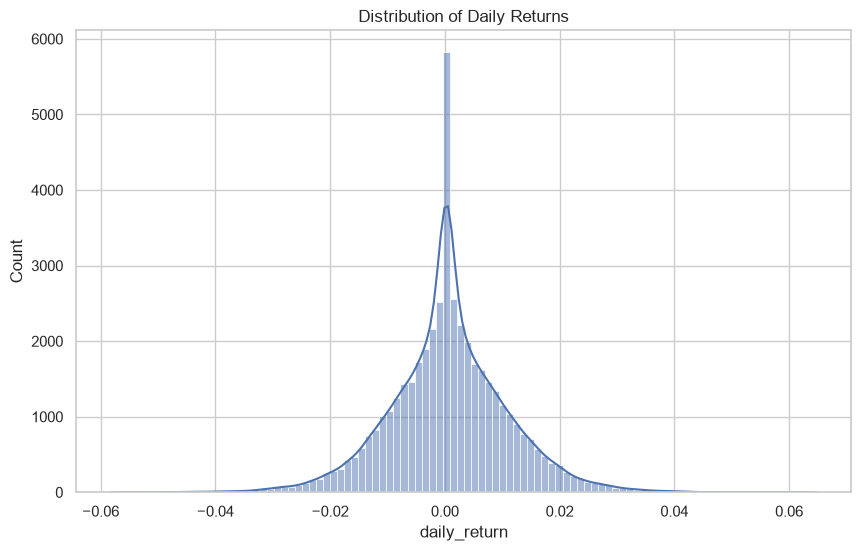

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [13]:
nav.to_csv(
    "../data/processed/nav_with_returns.csv",
    index=False
)

In [14]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [15]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [17]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [18]:
results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    total_days = (df.iloc[-1]["date"] - df.iloc[0]["date"]).days

    years = total_days / 365.25

    cagr = calculate_cagr(start_nav, end_nav, years)

    results.append({
        "amfi_code": fund,
        "CAGR_%": round(cagr, 2)
    })

In [19]:
results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    total_days = (df.iloc[-1]["date"] - df.iloc[0]["date"]).days

    years = total_days / 365.25

    cagr = calculate_cagr(start_nav, end_nav, years)

    results.append({
        "amfi_code": fund,
        "CAGR_%": round(cagr, 2)
    })

In [21]:
len(results)

40

In [22]:
cagr_df = pd.DataFrame(results)

cagr_df.head()

,amfi_code,CAGR_%
0,100016,2.64
1,100025,4.46
2,100033,30.12
3,101206,23.54
4,101207,7.94


In [24]:
cagr_df = cagr_df.sort_values(
    by="CAGR_%",
    ascending=False
)

cagr_df.head(10)

,amfi_code,CAGR_%
25,120505,32.83
21,119598,32.42
39,149324,32.29
36,148569,31.95
34,148567,30.97
30,120843,30.91
2,100033,30.12
38,149323,29.58
16,119094,28.21
19,119551,25.80


In [25]:
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

C:\Users\sahiltadavi\AppData\Local\Temp\ipykernel_18872\2452359257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


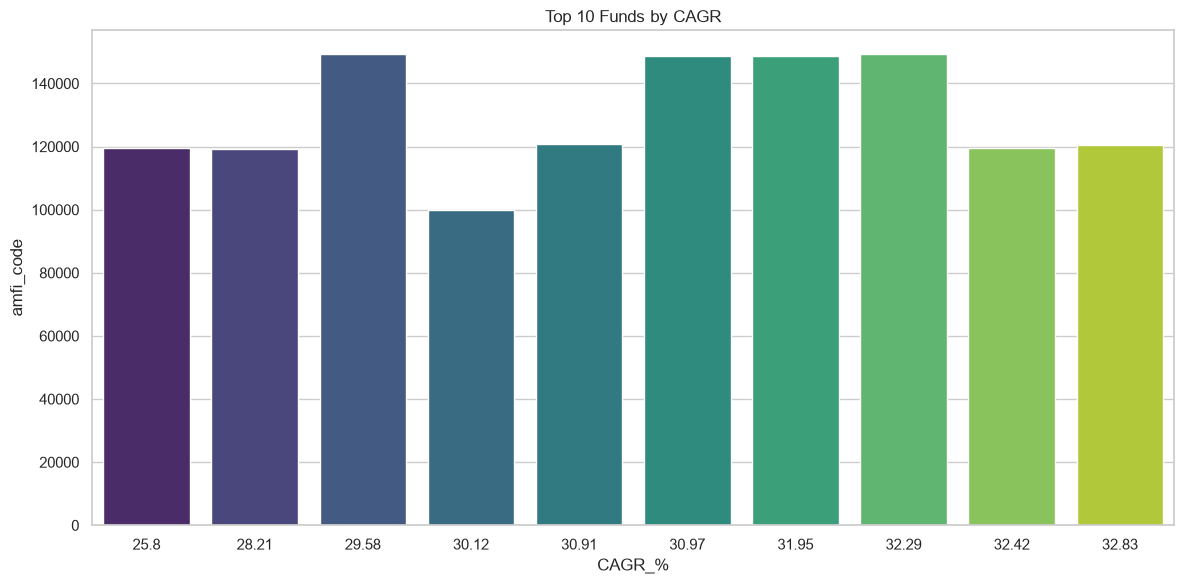

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=cagr_df.head(10),
    x="CAGR_%",
    y="amfi_code",
    palette="viridis"
)

plt.title("Top 10 Funds by CAGR")

plt.tight_layout()

plt.savefig("../reports/top10_cagr.png", dpi=300)

plt.show()

In [27]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [28]:
risk_free_rate = 0.065      # 6.5%
daily_rf = risk_free_rate / 252

In [29]:
import numpy as np

sharpe_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    excess_return = returns.mean() - daily_rf

    sharpe = (excess_return / returns.std()) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund,
        "Sharpe Ratio": round(sharpe, 3)
    })

In [30]:
import numpy as np

sharpe_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    excess_return = returns.mean() - daily_rf

    sharpe = (excess_return / returns.std()) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund,
        "Sharpe Ratio": round(sharpe, 3)
    })

In [32]:
sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe Ratio
34,148567,1.448
30,120843,1.307
36,148569,1.235
19,119551,1.208
25,120505,1.180
38,149323,1.132
2,100033,1.094
9,118632,1.082
3,101206,1.027
24,120504,1.027


In [33]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

C:\Users\sahiltadavi\AppData\Local\Temp\ipykernel_18872\479273589.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


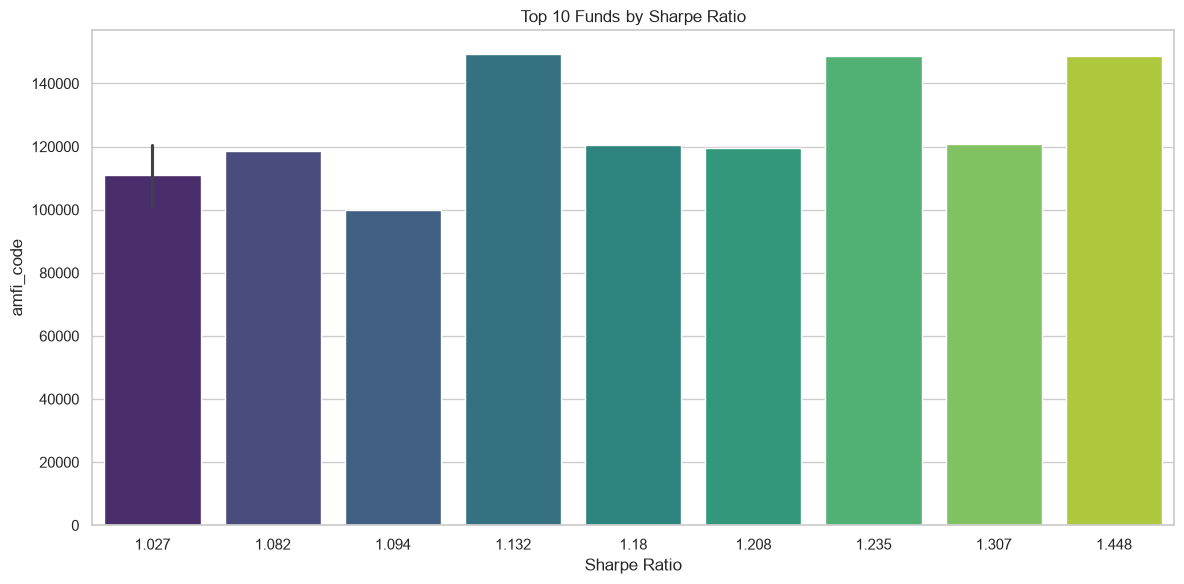

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="Sharpe Ratio",
    y="amfi_code",
    palette="viridis"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sharpe_ratio.png",
    dpi=300
)

plt.show()

In [35]:
import numpy as np

risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [36]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    excess_return = returns.mean() - daily_rf

    downside = returns[returns < 0]

    if len(downside) == 0:
        downside_std = np.nan
    else:
        downside_std = downside.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (excess_return / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": fund,
        "Sortino Ratio": round(sortino,3)
    })

In [37]:
sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    by="Sortino Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino Ratio
34,148567,2.386
30,120843,2.364
36,148569,2.147
19,119551,2.140
25,120505,2.029
38,149323,1.875
9,118632,1.850
2,100033,1.829
24,120504,1.805
3,101206,1.800


In [38]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

C:\Users\sahiltadavi\AppData\Local\Temp\ipykernel_18872\3072415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


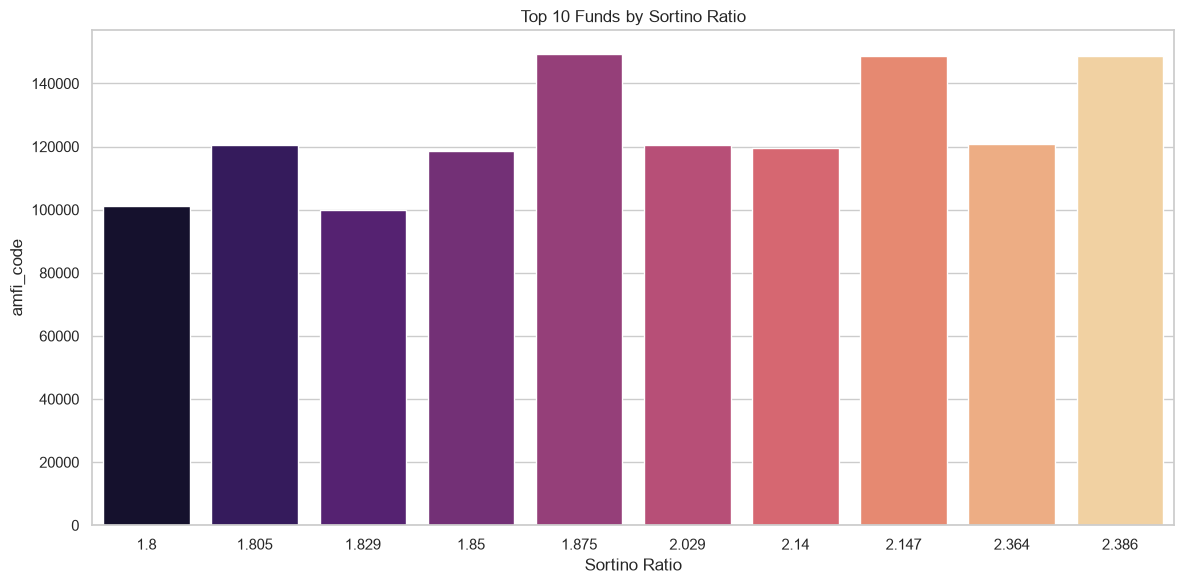

In [39]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_df.head(10),
    x="Sortino Ratio",
    y="amfi_code",
    palette="magma"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio.png",
    dpi=300
)

plt.show()

C:\Users\sahiltadavi\AppData\Local\Temp\ipykernel_18872\3072415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


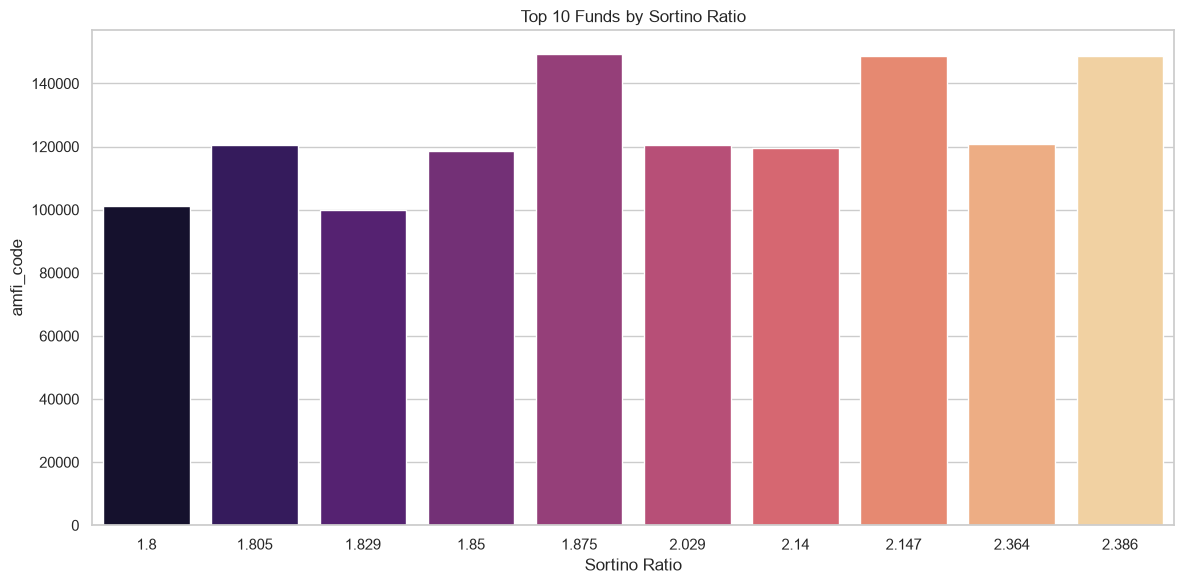

In [40]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_df.head(10),
    x="Sortino Ratio",
    y="amfi_code",
    palette="magma"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio.png",
    dpi=300
)

plt.show()

In [41]:
from scipy.stats import linregress

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Find Nifty 100 column automatically
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [43]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [44]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [45]:
from scipy.stats import linregress
import pandas as pd
import numpy as np

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Benchmark daily returns
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

# Use NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].copy()
    df = df.sort_values("date")

    df["fund_return"] = df["nav"].pct_change()

    merged = df.merge(
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    beta, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["fund_return"]
    )

    alpha = intercept * 252

    results.append({
        "amfi_code": fund,
        "Alpha": alpha,
        "Beta": beta,
        "R_squared": r_value**2
    })

alpha_beta = pd.DataFrame(results)

alpha_beta = alpha_beta.sort_values(
    "Alpha",
    ascending=False
)

alpha_beta.head()

,amfi_code,Alpha,Beta,R_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04


In [46]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [48]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"]==fund].copy()

    df = df.sort_values("date")

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = df["nav"]/df["running_max"]-1

    idx = df["drawdown"].idxmin()

    drawdowns.append({

        "amfi_code": fund,

        "Maximum Drawdown": df.loc[idx,"drawdown"],

        "Date": df.loc[idx,"date"]

    })

drawdown_df = pd.DataFrame(drawdowns)

drawdown_df = drawdown_df.sort_values(
    "Maximum Drawdown"
)

drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

drawdown_df.head()

,amfi_code,Maximum Drawdown,Date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14


In [53]:
print(sharpe_df.columns)
sharpe_df.head()

Index(['amfi_code', 'Sharpe Ratio'], dtype='str')


,amfi_code,Sharpe Ratio
34,148567,1.448
30,120843,1.307
36,148569,1.235
19,119551,1.208
25,120505,1.180


In [54]:
sharpe_df = sharpe_df.rename(columns={
    "Sharpe Ratio": "Sharpe"
})

sharpe_df.head()

,amfi_code,Sharpe
34,148567,1.448
30,120843,1.307
36,148569,1.235
19,119551,1.208
25,120505,1.180


In [63]:
scorecard = cagr_df.copy()

# Sharpe
scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

# Sortino
scorecard = scorecard.merge(
    sortino_df,
    on="amfi_code"
)

# Alpha
scorecard = scorecard.merge(
    alpha_beta[["amfi_code","Alpha"]],
    on="amfi_code"
)

# Max Drawdown
scorecard = scorecard.merge(
    drawdown_df[["amfi_code","Maximum Drawdown"]],
    on="amfi_code"
)

In [59]:
%whos DataFrame

Variable      Type         Data/Info
------------------------------------
alpha_beta    DataFrame    Shape: (40, 4)
benchmark     DataFrame    Shape: (8050, 4)
cagr_df       DataFrame    Shape: (40, 2)
df            DataFrame    Shape: (1150, 6)
drawdown_df   DataFrame    Shape: (40, 3)
merged        DataFrame    Shape: (1149, 6)
nav           DataFrame    Shape: (46000, 4)
nifty100      DataFrame    Shape: (1150, 2)
scorecard     DataFrame    Shape: (40, 3)
sharpe_df     DataFrame    Shape: (40, 2)
sortino_df    DataFrame    Shape: (40, 2)


In [62]:
drawdown_df.columns

Index(['amfi_code', 'Maximum Drawdown', 'Date'], dtype='str')

In [65]:
# Ranking columns
scorecard["Return Rank"] = scorecard["CAGR_%"].rank(ascending=False)
scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)
scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["Expense Rank"] = scorecard["expense_ratio"].rank()
scorecard["Drawdown Rank"] = scorecard["Max Drawdown"].rank()

# Composite score
scorecard["Fund Score"] = (
    30 * scorecard["Return Rank"] / 40 +
    25 * scorecard["Sharpe Rank"] / 40 +
    20 * scorecard["Alpha Rank"] / 40 +
    15 * scorecard["Expense Rank"] / 40 +
    10 * scorecard["Drawdown Rank"] / 40
)

scorecard["Fund Score"] = (
    scorecard["Fund Score"] /
    scorecard["Fund Score"].max()
) * 100

scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
)

scorecard.head()

KeyError: 'Sharpe Ratio'

In [66]:
sharpe_df.columns


Index(['amfi_code', 'Sharpe'], dtype='str')

In [67]:
print(cagr_df.columns)
print(sharpe_df.columns)
print(alpha_beta.columns)
print(drawdown_df.columns)

Index(['amfi_code', 'CAGR_%'], dtype='str')
Index(['amfi_code', 'Sharpe'], dtype='str')
Index(['amfi_code', 'Alpha', 'Beta', 'R_squared'], dtype='str')
Index(['amfi_code', 'Maximum Drawdown', 'Date'], dtype='str')


In [68]:
scorecard = cagr_df.copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code","Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code","Maximum Drawdown"]],
    on="amfi_code"
)

In [69]:
scorecard = cagr_df.copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code","Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code","Maximum Drawdown"]],
    on="amfi_code"
)

In [70]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

In [71]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

In [72]:
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav3 = nav[nav["date"] >= start_date].copy()

nifty50 = nifty50[nifty50["date"] >= start_date].copy()

nifty100 = nifty100[nifty100["date"] >= start_date].copy()

In [73]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[120505, 119598, 149324, 148569, 148567]

In [74]:
fig = go.Figure()

for fund in top5:

    df = nav3[nav3["amfi_code"] == fund].copy()

    df = df.sort_values("date")

    df["Normalized"] = (
        df["nav"] /
        df["nav"].iloc[0]
    ) * 100

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["Normalized"],
            mode="lines",
            name=str(fund)
        )
    )

In [75]:
nifty50["Normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

fig.add_trace(
    go.Scatter(
        x=nifty50["date"],
        y=nifty50["Normalized"],
        mode="lines",
        name="NIFTY50",
        line=dict(width=4)
    )
)

In [76]:
nifty100["Normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

fig.add_trace(
    go.Scatter(
        x=nifty100["date"],
        y=nifty100["Normalized"],
        mode="lines",
        name="NIFTY100",
        line=dict(width=4)
    )
)

In [77]:
fig.update_layout(

    title="Top 5 Mutual Funds vs NIFTY50 & NIFTY100",

    xaxis_title="Date",

    yaxis_title="Normalized Value (Base = 100)",

    template="plotly_white",

    width=1500,

    height=800
)

fig.show()

In [78]:
for trace in fig.data:
    trace.x = [str(x)[:10] for x in trace.x]

fig.write_image(
    "../reports/benchmark_comparison.png",
    width=1800,
    height=900
)

In [79]:
tracking = []

nifty100_returns = nifty100.copy()

nifty100_returns["Return"] = (
    nifty100_returns["close_value"]
    .pct_change()
)

for fund in top5:

    df = nav3[
        nav3["amfi_code"] == fund
    ].copy()

    df["Return"] = df["nav"].pct_change()

    merged = pd.merge(
        df[["date","Return"]],
        nifty100_returns[["date","Return"]],
        on="date",
        suffixes=("_fund","_benchmark")
    ).dropna()

    tracking_error = (
        (merged["Return_fund"] -
         merged["Return_benchmark"]).std()
        * np.sqrt(252)
    )

    tracking.append({
        "amfi_code": fund,
        "Tracking Error": tracking_error
    })

tracking_df = pd.DataFrame(tracking)

tracking_df

,amfi_code,Tracking Error
0,120505,0.232661
1,119598,0.286689
2,149324,0.279036
3,148569,0.217062
4,148567,0.187974


In [80]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)